<a href="https://colab.research.google.com/github/kyungeunvoyage/MotionDualAxisVib/blob/main/Waveform_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Waveform Visualizer: `test` (int16, 256 samples)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Original int16 array (256 samples)
wave_impulseDampedTail = np.array([
    32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767,
    32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 194, 581, 967, 1353, 1738, 2122,
    2504, 2886, 3266, 3644, 4020, 4395, 4767, 5138, 5505, 5871, 6234, 6594, 6951, 7305, 7656, 8004,
    8348, 8688, 9025, 9358, 9688, 10013, 10334, 10650, 10962, 11270, 11573, 11871, 12164, 12452, 12735, 13013,
    13286, 13553, 13815, 14071, 14321, 14566, 14804, 15037, 15263, 15484, 15698, 15906, 16108, 16303, 16491, 16673,
    16849, 17017, 17179, 17334, 17482, 17624, 17758, 17885, 18005, 18118, 18224, 18323, 18414, 18499, 18576, 18645,
    18708, 18763, 18810, 18851, 18884, 18909, 18928, 18938, 18942, 18938, 18927, 18908, 18882, 18849, 18809, 18761,
    18706, 18644, 18574, 18498, 18414, 18323, 18226, 18121, 18009, 17891, 17765, 17633, 17494, 17348, 17196, 17037,
    16872, 16700, 16522, 16338, 16148, 15951, 15749, 15540, 15326, 15106, 14880, 14649, 14412, 14170, 13923, 13670,
    13412, 13150, 12882, 12610, 12333, 12052, 11766, 11476, 11181, 10883, 10581, 10274, 9965, 9651, 9334, 9014,
    8691, 8364, 8035, 7702, 7367, 7030, 6690, 6348, 6003, 5657, 5309, 4959, 4607, 4254, 3900, 3544,
    3188, 2830, 2472, 2113, 1754, 1394, 1035, 675, 315, -45, -404, -763, -1121, -1479, -1835, -2191,
    -2545, -2898, -3249, -3599, -3947, -4293, -4638, -4980, -5320, -5657, -5992, -6325, -6654, -6981, -7305, -7625,
    -7942, -8256, -8567, -8873, -9177, -9476, -9771, -10062, -10349, -10632, -10910, -11184, -11453, -11717, -11977, -12232,
    -12481, -12726, -12966, -13200, -13429, -13652, -13870, -14082, -14289, -14490, -14685, -14874, -15058, -15235, -15406, -15571,
    -15730, -15882, -16029, -16168, -16302, -16429, -16549, -16663, -16771, -16871, -16965, -17053, -17133, -17207, -17275, -17335
], dtype=np.int16)

len(wave_impulseDampedTail), wave_impulseDampedTail[:10]

(256,
 array([32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767, 32767,
        32767], dtype=int16))

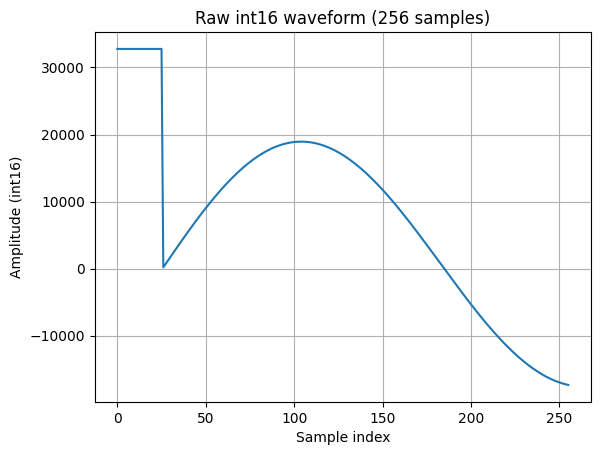

In [2]:
plt.figure()
plt.plot(wave_impulseDampedTail)
plt.title("Raw int16 waveform (256 samples)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude (int16)")
plt.grid(True)
plt.show()

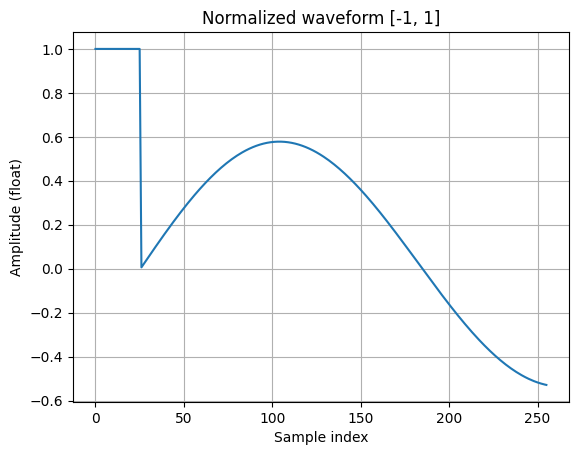

In [3]:
# Normalize to [-1, 1] float
norm = wave_impulseDampedTail.astype(np.float32) / 32768.0

plt.figure()
plt.plot(norm)
plt.title("Normalized waveform [-1, 1]")
plt.xlabel("Sample index")
plt.ylabel("Amplitude (float)")
plt.grid(True)
plt.show()

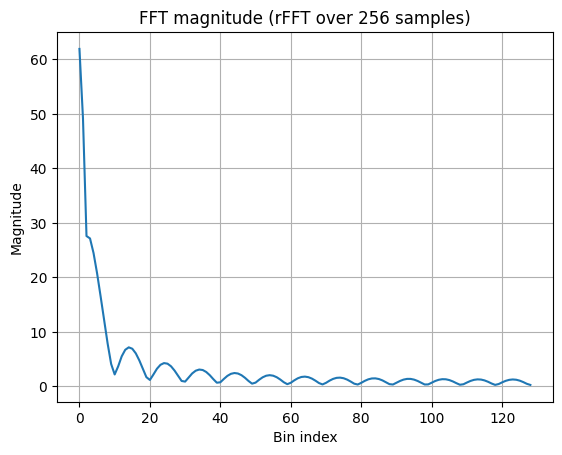

In [4]:
# Simple FFT magnitude (unitless). This is over the 256-sample single cycle (no real time).
fft = np.fft.rfft(norm)
mag = np.abs(fft)

plt.figure()
plt.plot(mag)
plt.title("FFT magnitude (rFFT over 256 samples)")
plt.xlabel("Bin index")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

In [5]:
# (Optional) Export to WAV for quick listening tests.
# Uses the built-in 'wave' module; no external dependencies needed.
import wave, struct

def export_wave(filename: str, int16_cycle: np.ndarray, sample_rate: int = 44100, seconds: float = 1.0):
    assert int16_cycle.dtype == np.int16
    # Tile the single 256-sample cycle to fill the requested duration
    total_samples = int(sample_rate * seconds)
    reps = int(np.ceil(total_samples / len(int16_cycle)))
    tiled = np.tile(int16_cycle, reps)[:total_samples]

    with wave.open(filename, 'wb') as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)  # int16 = 2 bytes
        wf.setframerate(sample_rate)
        # Pack as little-endian 16-bit signed integers
        wf.writeframes(struct.pack('<' + 'h'*len(tiled), *tiled.tolist()))
    return filename

# Example usage (uncomment to run and generate a file):
# out_path = export_wave('wave_impulseDampedTail_1s.wav', wave_impulseDampedTail, sample_rate=44100, seconds=1.0)
# out_path